## Neural analysis results for DD paper
(on sciencecloud with /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk as main bids_folder)
all visualizations & statistics 


- nPRFs  (between group test)
- NPC dispersion (between group test)
- PFM in NPC (correlations with NPC-dispersion & between group tests)
    - whole brain PFM between group tests in `paper_cloud_supplements_01`

In [ ]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt
import seaborn as sns


from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()
N_vertices = len(np.where(mask==True)[0])

dataset ='dnumrisk'
bids_folder = f'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-{dataset}'
plots_folder = op.join(bids_folder, 'plots_and_ims', 'paper_01')
phenotype_folder = op.join(bids_folder, 'derivatives','phenotype')

subList = [f'{int(sub):02d}' for sub in range(1, 67)]
group_list =  pd.read_csv(op.join(bids_folder, 'group_mapping.csv'), header=0, index_col=0)
group_list['group'] = np.where(group_list['group'] == 0, 'Control', 'Dyscalculic')


In [3]:
from numrisk.fmri_analysis.gradients.utils import get_NPC_mask, get_basic_mask

mask, labeling_noParcel = get_basic_mask()
npc_mask = get_NPC_mask()

In [4]:
import hcp_utils as hcp
from matplotlib.colors import ListedColormap
rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
grey = np.array([[0.5, 0.5, 0.5, 1.0]])  # RGBA format: grey with full opacity
cmap_ca = ListedColormap( np.vstack([grey, rgb]))

fsaverage = fetch_surf_fsaverage('fsaverage5')

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [22]:
from scipy.stats import normaltest, ttest_ind, mannwhitneyu, ttest_rel

def between_group_test(df_tmp, y_var, alpha=0.05):
    pval_normal = normaltest(df_tmp[y_var]).pvalue
    if 'group' not in df_tmp.columns:
           df_tmp = df_tmp.reset_index('group')

    group1 = df_tmp[df_tmp['group'] == 'Control'][y_var].dropna()
    group2 = df_tmp[df_tmp['group'] == 'Dyscalculic'][y_var].dropna()

    if pval_normal > alpha:
            stats = ttest_ind(group1, group2, axis=0)
            stats_term = f't({len(group1)+len(group2)-2})'
    else: # non parametric test
            stats = mannwhitneyu(group1, group2, axis=0)
            stats_term = f'U({len(group1)}, {len(group2)})'
    return stats, stats_term



## Neural Number sense

r - normal distribution (fail to reject H0)
TtestResult(statistic=-0.15137739830488958, pvalue=0.8801617118515485, df=63.0)


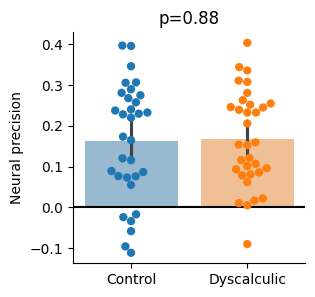

In [132]:
df_decode = pd.read_csv(op.join(phenotype_folder, 'decoding_r.csv')).set_index('subject').join(group_list, on='subject')
y_var = 'r'

tmp = df_decode.set_index('group', append=True)
figure, axes = plt.subplots(1, 1,figsize = (3,3))
sns.barplot(data=tmp.reset_index(), x ='group',y=y_var, alpha=0.5, hue='group' ,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])

if pval_normal > alpha:
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs('Control',0,'group')[y_var], tmp.xs('Dyscalculic',0,'group')[y_var], axis=0)

axes.set(title=f'p={stats.pvalue:.2f}',
    ylabel='Neural precision', xlabel=None)#,ylim=[0,15])
axes.axhline(0, color='black')#, linestyle='--')
sns.despine()
print(stats)
plt.savefig(op.join(plots_folder,f'NeuralPrecision_r.pdf'), dpi=300, bbox_inches='tight')

### Average nPRF-R2 maps 

In [5]:
group = 'all'
fn_l = f'/mnt_03/ds-dnumrisk/derivatives/encoding_model.denoise/averages/group-{group}_desc-r2.optim.nilearn_space-fsaverage_hemi-L.func.gii'
surf_mapL = nib.load(fn_l).agg_data()
fn_r = f'/mnt_03/ds-dnumrisk/derivatives/encoding_model.denoise/averages/group-{group}_desc-r2.optim.nilearn_space-fsaverage_hemi-R.func.gii'
surf_mapR = nib.load(fn_r).agg_data()

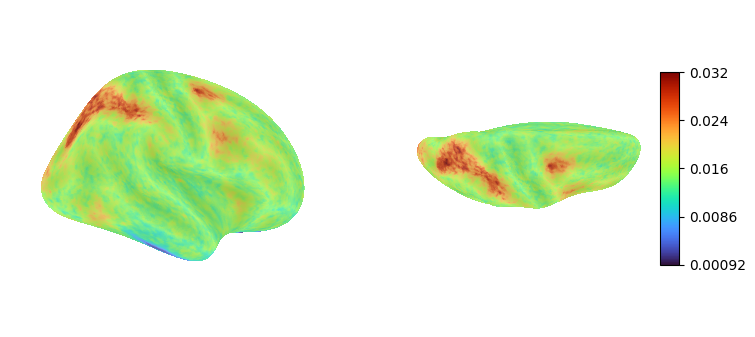

In [8]:
fsaverage = fetch_surf_fsaverage('fsaverage')
cmap = 'turbo' 
figure, axes = plt.subplots(nrows=1, ncols=2, figsize=(9,5),subplot_kw=dict(projection='3d'))

for i, view in enumerate(['medial', 'dorsal']):
    colorbar = True if i == 1 else False
    nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= surf_mapR, # infl_right # pial_right
                view= view,cmap=cmap, colorbar=colorbar, axes=axes[i],  
                bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7)
plt.savefig(op.join(plots_folder,f'nPRF_averageR2map.pdf'), dpi=300, bbox_inches='tight')

## Connectivity

In [ ]:
fsaverage = fetch_surf_fsaverage('fsaverage5')

In [7]:
sub = 'All' 
kernel = 'normalized_angle'  #
ztransf = True
avMethod = 'tanH'
specification = f'kernel-{kernel}_ztransf-{ztransf}_avMethod-{avMethod}'

source_dir = op.join(bids_folder,'derivatives','gradients.tryParams.36P', f'sub-{sub}')
grad = np.load(op.join(source_dir,f'sub-{sub}_gradients_{specification}.npy'))

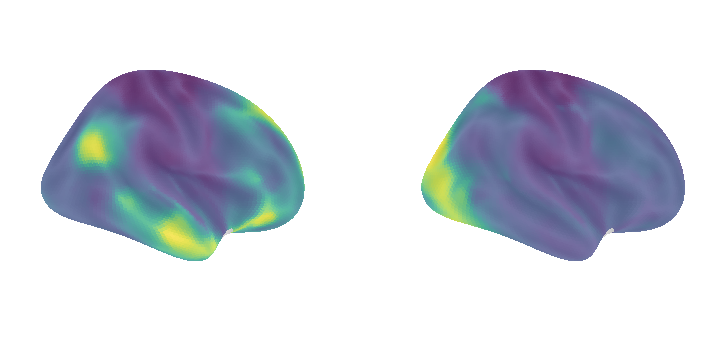

In [44]:
figure, axes = plt.subplots(nrows=1, ncols=2, figsize=(9,5),subplot_kw=dict(projection='3d'))
view = 'medial'
cmap = 'viridis'

for i, grad_i in enumerate([1,2]):
    gm_r = np.split(grad[i], 2)[1] # for i, hemi in enumerate([‘L’, ‘R’]): --> left first
    nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, 
                view= view,cmap=cmap, colorbar=False, axes=axes[i],  
                bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.5)
plt.savefig(op.join(plots_folder,f'average_gradients.pdf'), dpi=300, bbox_inches='tight')

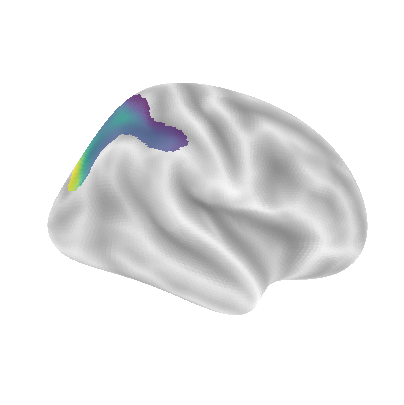

In [16]:
view = 'dorsal'
cmap = 'viridis'

i, grad_i = 1,2
gm_fsav5 = grad[i]
gm_fsav5[~npc_mask] = np.nan 
gm_r = np.split(gm_fsav5, 2)[1] # for i, hemi in enumerate([‘L’, ‘R’]): --> left first

figure, axes = plt.subplots(nrows=1, ncols=1, figsize=(5,5),subplot_kw=dict(projection='3d'))
nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, 
            view= view,cmap=cmap, colorbar=False, axes=axes,  
            bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.5)
plt.savefig(op.join(plots_folder,f'NPCdispersion_brainSurf_Inlet_{view}.pdf'), dpi=300, bbox_inches='tight', transparent=True)

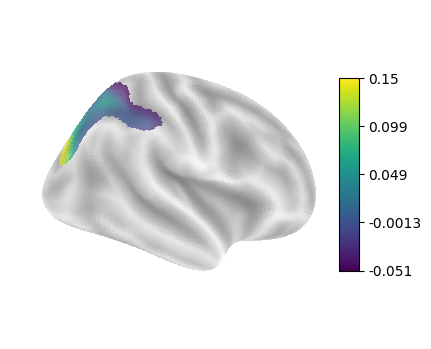

In [17]:
figure, axes = plt.subplots(nrows=1, ncols=1, figsize=(5,5),subplot_kw=dict(projection='3d'))
nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, 
            view= view,cmap=cmap, colorbar=True, axes=axes,  
            bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.5)
plt.savefig(op.join(plots_folder,f'colorbar_gradient.pdf'), dpi=300, bbox_inches='tight', transparent=True)

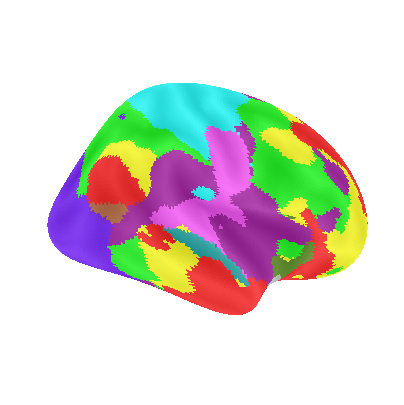

In [49]:
sub = 'average'
confspec = '36Pscrub3BPfilter'
target_folder = op.join(bids_folder,'derivatives','networks_infomap_full')
fn_consens_mapping = op.join(target_folder, f'sub-{sub}_consensusMapping_confspec-{confspec}.npy')
consensus_labels = np.load(fn_consens_mapping)
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] = consensus_labels

modules_fsav5_hemi = np.split(modules_fsav5,2)[1]

figure, axes = plt.subplots(nrows=1, ncols=1,figsize = (5,5), subplot_kw=dict(projection='3d'))
nplt.plot_surf(surf_mesh=fsaverage.infl_right , surf_map= modules_fsav5_hemi, avg_method = 'median',# infl_right # pial_right
        view= view,cmap=cmap_ca, colorbar=False,
        vmin = 0, vmax=12,
        bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7, axes=axes) 
plt.savefig(op.join(plots_folder,f'average_PFmap_CAcolors.pdf'), dpi=300, bbox_inches='tight')

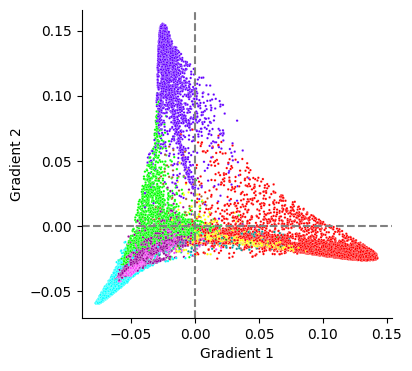

In [69]:
df = pd.DataFrame(np.array([grad[0], grad[1],modules_fsav5]).T, columns =['g1','g2','ca_network'])

fig, axs = plt.subplots(1,1,figsize=(4,4))
sns.scatterplot(df, x='g1', y='g2', hue='ca_network',palette=cmap_ca,s=3, legend=False,
                 hue_order=range(1, 13), hue_norm=plt.Normalize(0, 12))
sns.despine()
axs.axvline(0, color='grey', linestyle='--')
axs.axhline(0, color='grey', linestyle='--')
axs.set(xlabel='Gradient 1', ylabel = 'Gradient 2')
plt.savefig(op.join(plots_folder,f'average_gradientCoorSyst_PFmapColorLabels.pdf'), dpi=300, bbox_inches='tight')

### GM - NPC dispersion

In [18]:
n_gradients = 3
aligned = True # False only for eccentricity or 2D dispersion?
alignRef = 'tanH'
kernel ='normalized_angle' #  None #
ztransf = True #'True_ccfilter'
specification = f'kernel-{kernel}_ztransf-{ztransf}'
source_folder = op.join(bids_folder,'derivatives','gradients.tryParams.36P')

import glob
n_gradients = 3
gms = {f'g{i+1}': [] for i in range(n_gradients)}
for sub in subList:
    source_folder_gm =  op.join(source_folder,f'sub-{sub}')
    sub_file_pattern = op.join(source_folder_gm,f'sub-{sub}_g-aligned-{alignRef}_{specification}*.npy') if aligned else op.join(source_folder_gm,f'sub-{sub}_gradients_{specification}*.npy')
    fn = glob.glob(sub_file_pattern)[0]
    gm= np.load(fn)
    for i in range(n_gradients):
        gms[f'g{i+1}'].append(gm[i, :])

sub_array = np.array([int(i) for i in subList])

dfs = []
for i in range(n_gradients):
    gradient_df = pd.DataFrame(gms[f'g{i+1}'], index=sub_array)
    gradient_df.index.name = 'subject'
    #gradient_df = gradient_df.join(group_list, on='subject').set_index('group', append=True)
    gradient_df['n_gradient'] = i + 1
    dfs.append(gradient_df.set_index('n_gradient', append=True))

df_gms = pd.concat(dfs).sort_index(level='n_gradient')

In [20]:
# dispersion measures - does not work..?!

df_onlyNPC = df_gms[np.where(npc_mask)[0]] # carful, does not give error if mask is applied and shapes would actuallt not match!
df_onlyNPC_means = pd.DataFrame(df_onlyNPC.median(axis=1), columns=['mean'])
df_onlyNPC_centered_squared = df_onlyNPC.sub(df_onlyNPC_means['mean'], axis=0)**2 # (val - mean)**2

df_npc_dispersion_2d = (df_onlyNPC_centered_squared.xs(1, level='n_gradient') + #  df_onlyNPC_centered_squared.xs(3, level='n_gradient')
                        df_onlyNPC_centered_squared.xs(2, level='n_gradient')).mean(axis=1).to_frame(name='NPC_dispersion').join(group_list, on='subject')
df_npc_dispersion_grad1 = (df_onlyNPC_centered_squared.xs(1, level='n_gradient')).mean(axis=1).to_frame(name='NPC_dispersion').join(group_list, on='subject')
df_npc_dispersion_grad2 = (df_onlyNPC_centered_squared.xs(2, level='n_gradient')).mean(axis=1).to_frame(name='NPC_dispersion').join(group_list, on='subject')

NPC_dispersion - not normal distribution (reject H0)
MannwhitneyuResult(statistic=317.0, pvalue=0.00360096804783769)


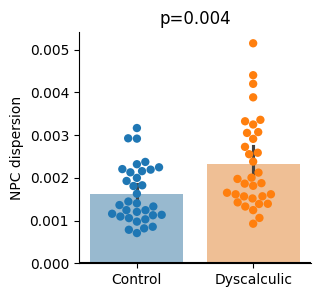

In [103]:
y_var = 'NPC_dispersion'
tmp = df_npc_dispersion_2d.set_index('group', append=True)

alpha = 0.05
figure, axes = plt.subplots(1, 1,figsize = (3,3))
sns.barplot(data=tmp.reset_index(), x ='group',y=y_var, alpha=0.5, hue='group' ,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])

if pval_normal > alpha:
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs('Control',0,'group')[y_var], tmp.xs('Dyscalculic',0,'group')[y_var], axis=0)
else: # non parametric test
        print(f'{y_var} - not normal distribution (reject H0)')    
        stats = mannwhitneyu(tmp.xs('Control',0,'group')[y_var], tmp.xs('Dyscalculic',0,'group')[y_var], axis=0)
axes.set(title=f'p={stats.pvalue:.3f}',
    ylabel='NPC dispersion', xlabel=None)#,ylim=[0,15])
axes.axhline(0, color='black')#, linestyle='--')
sns.despine()
print(stats)
plt.savefig(op.join(plots_folder,f'NPC_dispersion_2D.pdf'), dpi=300, bbox_inches='tight')

In [30]:
# Non squared distances to NPC-mean in gradient space
df_onlyNPC_centered = df_onlyNPC.sub(df_onlyNPC_means['mean'], axis=0) # (val - mean)**2
df_npc_summed_distances = (df_onlyNPC_centered.xs(1, level='n_gradient') + df_onlyNPC_centered.xs(2, level='n_gradient')).join(group_list, on='subject')
group_NPC_distance_2d = df_npc_summed_distances.groupby('group').mean().T.stack('group').reset_index('group')


In [28]:
g1 = df_onlyNPC_centered.xs(1, level='n_gradient')
g2 = df_onlyNPC_centered.xs(2, level='n_gradient')
negative_mask = (g1 < 0) | (g2 < 0)
summed_distance = (g1.abs() + g2.abs()) * (-1 * negative_mask.astype(int) + (~negative_mask).astype(int))
group_NPC_distance_2d = summed_distance.join(group_list, on='subject').groupby('group').mean().T.stack('group').reset_index('group')

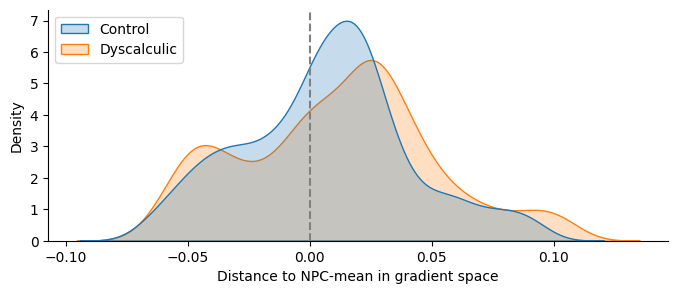

In [31]:
fig, axes = plt.subplots(1, 1,figsize = (8,3))
sns.kdeplot(group_NPC_distance_2d, x=0,hue='group', fill=True, ax=axes)
axes.set(xlabel='Distance to NPC-mean in gradient space') #, xticklabels='')
sns.despine()
leg = axes.get_legend()
leg.set_title(None)
leg.set_loc('upper left')  

axes.axvline(0, color='grey', linestyle='--')
#plt.savefig(op.join(plots_folder,f'NPC_dispersion_illustration.pdf'), dpi=300, bbox_inches='tight')
plt.show()


## PFM 

overview aalysis plots in `parietal_patterns/networks_indTopology/groupComp_DD_01.ipynb`

In [ ]:
net_folder = op.join(bids_folder, 'derivatives', 'networks_infomap_full_01')

from numrisk.fmri_analysis.gradients.utils import get_glasser_CAatlas_mapping
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

df_nets_counts = pd.DataFrame(columns=[f'net_{x}' for x in range(2, 10)], index=range(1, 67), dtype=float)
df_nets_counts.index.name = 'subject'
df_nets_counts = df_nets_counts.join(group_list).set_index(['group'], append=True)

only_NPC = True 
hemi = 'both'

for sub in subList:
    try:
        nets = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))
        if only_NPC:
            nets_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
            nets_fsav5[mask] = nets
            nets = nets_fsav5[npc_mask]
        net_i, counts = np.unique(nets, return_counts=True)

        for net, count in zip(net_i, counts):
            df_nets_counts.loc[int(sub), f'net_{int(net)}'] = count

    except Exception as e:
        print(f'Error processing sub-{sub}: {e}')

df_nets_counts.drop('net_-1', axis=1, inplace=True)
#df_nets_counts.to_csv(op.join(phenotype_folder, f'sub_networks_counts_onlyNPC-{only_NPC}.csv'))

Error processing sub-02: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full_01/sub-02_consensusMapping_confspec-36Pscrub3BPfilter.npy'


In [33]:
# Correlation with NPC dispersion

df_npcDisp_wholeTS = pd.read_csv(op.join('/mnt_03/ds-dnumrisk', 'derivatives','phenotype', 'withinNdispersion-NPC_grad-2_confspec-36Pscrub3BPfilterrunFD104.csv')).set_index('subject')
df_comb = df_nets_counts.join(df_npcDisp_wholeTS, on='subject').drop('group', axis=1)

from scipy.stats import pearsonr
for net in [f'net_{n}' for n in [2,5,9]]:
    tmp = df_comb[['NPC_dispersion', net]].dropna()
    net_name =  CAatlas_names.loc[int(net[4])]['Network Name']
    stats = pearsonr(tmp['NPC_dispersion'],tmp[net])
    print(f'{net_name}: r={stats.statistic:.3f}, p={stats.pvalue:.3f}' )

Visual2: r=0.414, p=0.001
Dorsal-attention: r=-0.287, p=0.022
Default: r=0.410, p=0.001


In [ ]:
# Between group tests
for net in [f'net_{x}' for x in [2,5,9]]:
    stats, stats_term = between_group_test(df_nets_counts, y_var= net)
    net_name =  CAatlas_names.loc[int(net[4])]['Network Name']
    print(f'{net_name}:  {stats_term}={stats.statistic:.2f}, p={stats.pvalue:.3f}')

Visual2:  U(33, 32)=376.00, p=0.047
Dorsal-attention:  U(33, 32)=659.50, p=0.086
Default:  U(32, 32)=468.50, p=0.563


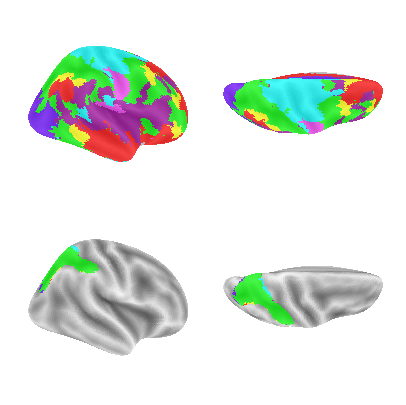

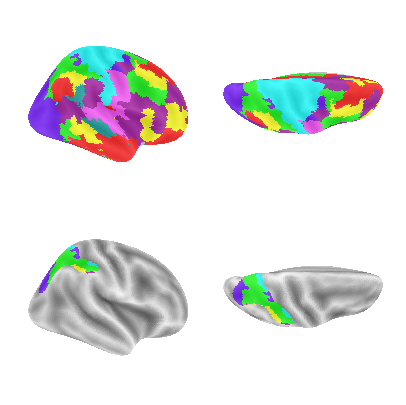

In [5]:
# cleaned version (removed small pieces)
views = ['medial','dorsal']
roi_settings = ['whole_brain', 'only_NPC']

for sub in ['01','45']:
    net_folder = op.join(bids_folder, 'derivatives', 'networks_infomap_full_01')
    modules_fsav5 = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter_cleaned_fsaverage5.npy'))

    figure, axes = plt.subplots(nrows=len(roi_settings), ncols=len(views),figsize = (5,5), subplot_kw=dict(projection='3d'))

    for i_row, roi_setting in enumerate(roi_settings):
        if roi_setting == 'only_NPC':
            modules_fsav5[~npc_mask] = np.nan 
        modules_fsav5_hemi = np.split(modules_fsav5,2)[1]
        for i_col, view in enumerate(views):
            nplt.plot_surf(surf_mesh=fsaverage.infl_right , surf_map= modules_fsav5_hemi, avg_method = 'median',# infl_right # pial_right
                    view= view,cmap=cmap_ca, colorbar=False, vmin = 0, vmax=12,
                    bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7, axes=axes[i_row, i_col]) 
            
    figure.subplots_adjust(wspace=0.01, hspace=0.01)
    plot_fn = op.join(plots_folder, f'PFMexampleMaps_sub-{sub}.pdf')
    figure.savefig(plot_fn, dpi=300, bbox_inches='tight', transparent=True)



## OLD / additional?

In [ ]:
for grad_n in [1,2]:
    df_npc_distances = df_onlyNPC_centered.xs(grad_n, level='n_gradient').join(group_list, on='subject')
    group_NPC_distances = df_npc_distances.groupby('group').mean().T.stack('group').reset_index('group')
    fig, axes = plt.subplots(1, 1,figsize = (6,2))
    sns.kdeplot(group_NPC_distances, x=0,hue='group', fill=True, ax=axes)
    axes.set(xlabel='Distance to NPC-mean in gradient space', title=f'Grad {grad_n}') #, xticklabels='')
    sns.despine()
    leg = axes.get_legend()
    leg.set_title(None)

grad_std - normal distribution (fail to reject H0)
grad_std - not normal distribution (reject H0)
grad_std - normal distribution (fail to reject H0)


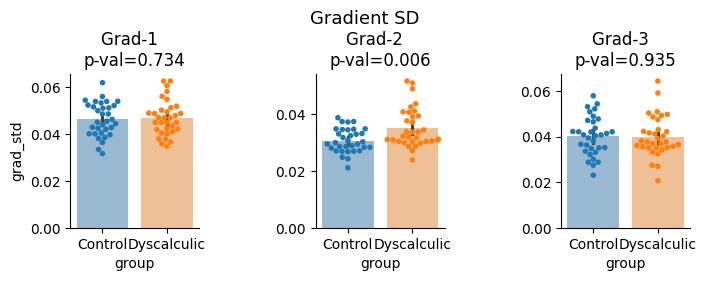

In [8]:
grad_variance = df_gms.std(axis=1).to_frame(name='grad_std').join(group_list, on='subject').set_index('group', append=True)

import seaborn as sns
alpha = 0.05
specification = ''
figure, axes = plt.subplots(1, 3,figsize = (2*4,2), sharey=False)

for i,n_grad in enumerate([1,2,3]):
    y_var =  'grad_std'#'grad_minmaxdiff' #
    tmp = grad_variance.xs(n_grad, level='n_gradient')#.drop(64)

    sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False, ax=axes[i])
    sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=4,legend=False, ax=axes[i])
    _, pval_normal = normaltest(tmp[y_var])
    if pval_normal > alpha:
            print(f'{y_var} - normal distribution (fail to reject H0)')
            stats = ttest_ind(tmp.xs('Control',0,'group')[y_var], tmp.xs('Dyscalculic',0,'group')[y_var], axis=0, equal_var=False)
    else: # non parametric test
            print(f'{y_var} - not normal distribution (reject H0)')    
            stats = mannwhitneyu(tmp.xs('Control',0,'group')[y_var], tmp.xs('Dyscalculic',0,'group')[y_var], axis=0)
    axes[i].set(title=f'Grad-{n_grad}  \np-val={stats.pvalue:.3f}',xlabel='group') #,ylim=[0.02, 0.065])
    axes[i].set_ylabel(y_var) if i==0 else axes[i].set_ylabel(None)
    sns.despine()
figure.suptitle(f'Gradient SD  ', y=1.2, fontsize=13)
figure.subplots_adjust(wspace=0.9)

In [ ]:
# NPC dispersion measure as in Biancas script 
# data array with N = 66 subjects
# net = NPC mask; 2 = gradient 1 & 2

G1_net = np.array(gms[f'g1']).T[npc_mask]
G2_net = np.array(gms[f'g2']).T[npc_mask]
G_net = np.stack([G1_net, G2_net], axis=-1)  # shape: number of nodes in network x N x 2
centroid_cog_net = np.nanmedian(G_net, axis=0)  # shape: N x 2

# Compute the 2D Euclidean distance between each node and the centroid for each subject
dist_nodes_to_centroid = G_net - centroid_cog_net  # shape: number of nodes in network x N x 2
squared_distances = np.sum(dist_nodes_to_centroid**2, axis=-1)  # sum squares across 2D (last axis), shape: number of nodes in network x N

# Compute the within-network dispersion as the mean squared distance
NPC_2d_dispersion =  np.nanmean(squared_distances, axis=0)  # shape: N
df_npc_dispersion_2d = pd.DataFrame(NPC_2d_dispersion.T, index=sub_array, columns=['NPC_2D_dispersion'])
df_npc_dispersion_2d.index.name = 'subject'
df_npc_dispersion_2d = df_npc_dispersion_2d.join(group_list).set_index('group',append=True)

df_npc_dispersion_2d_bianca = df_npc_dispersion_2d.copy()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66])